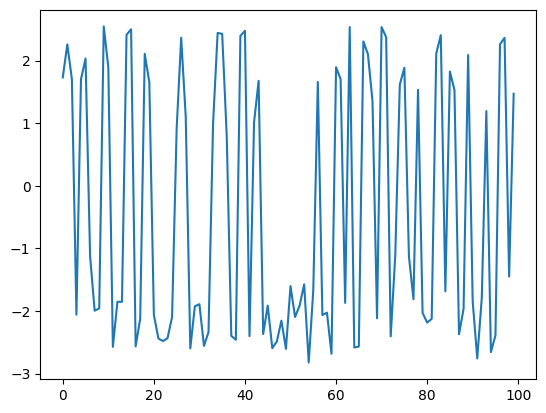

USB read error
USB read error
USB read error


(array([ 0.01884956, -3.2311355 ]), {})

In [4]:
import gym_unbalanced_disk
import gymnasium
import numpy as np
from matplotlib import pyplot as plt

#create inputs
umax = 3.0 
np.random.seed(46)
ulist = np.random.uniform(-1,1,size=1000)
from scipy import signal
f0 = 0.8
ulist = signal.lfilter(*signal.butter(6,f0),ulist)
ulist /= max(np.max(ulist),-np.min(ulist))
ulist = umax*abs(ulist)**(1/4)*np.sign(ulist) #push to limits

plt.plot(ulist[:100])
plt.show()

env = gym_unbalanced_disk.UnbalancedDisk_exp(umax = umax,dt = 0.025)

obs, info = env.reset()
ylist = []
for u in ulist:
    ylist.append(obs)
    obs, reward, terminal, truncated, info = env.step(u)
env.reset()


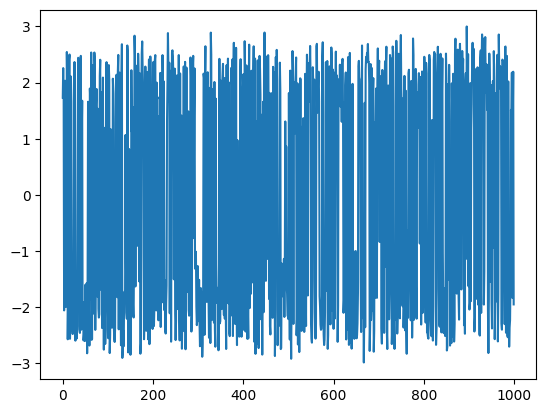

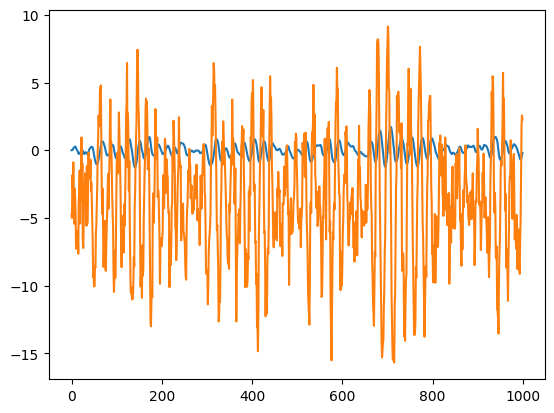

In [5]:
plt.plot(ulist) 
plt.show()
plt.plot(ylist)
plt.show()

In [6]:
env.close()

In [7]:
env = gymnasium.make('unbalanced-disk-exp-v0', dt=0.025, umax=3.) #both are equivalent (this one has a time limit build in)
env = gym_unbalanced_disk.UnbalancedDisk(dt=0.025, umax=3.) #both are equivalent

### Load model and run it on the setup

k=000 obs=[ 0.     1.    -2.791] model_u=+0.554 applied_u=+0.554
k=001 obs=[ 0.     1.    -4.551] model_u=+0.140 applied_u=+0.140
k=002 obs=[ 3.000e-03  1.000e+00 -3.171e+00] model_u=+0.416 applied_u=+0.416
k=003 obs=[ 0.009  1.    -2.499] model_u=+0.702 applied_u=+0.702
k=004 obs=[ 0.013  1.    -4.511] model_u=+0.149 applied_u=+0.149
k=005 obs=[ 0.022  1.    -3.611] model_u=+0.306 applied_u=+0.306
k=006 obs=[ 0.031  1.    -3.723] model_u=+0.285 applied_u=+0.285
k=007 obs=[ 0.035  0.999 -2.991] model_u=+0.499 applied_u=+0.499
k=008 obs=[ 0.038  0.999 -2.551] model_u=+0.700 applied_u=+0.700
k=009 obs=[ 0.041  0.999 -1.579] model_u=+1.475 applied_u=+1.475
k=010 obs=[ 0.044  0.999 -3.391] model_u=+0.374 applied_u=+0.374
k=011 obs=[ 0.06   0.998 -4.066] model_u=+0.229 applied_u=+0.229
k=012 obs=[ 0.082  0.997 -2.479] model_u=+0.776 applied_u=+0.776
k=013 obs=[ 0.097  0.995 -1.107] model_u=+2.283 applied_u=+2.283
k=014 obs=[ 0.107  0.994 -3.099] model_u=+0.501 applied_u=+0.501
k=015 obs=[ 0

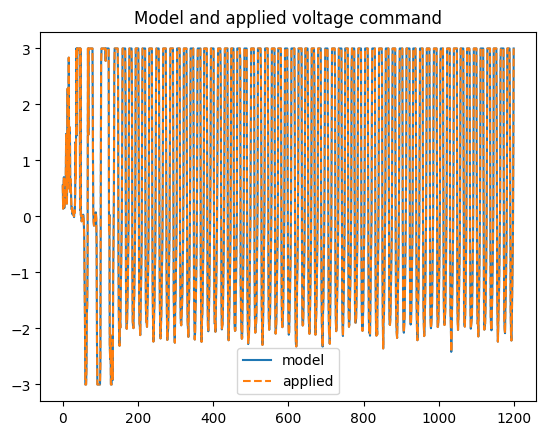

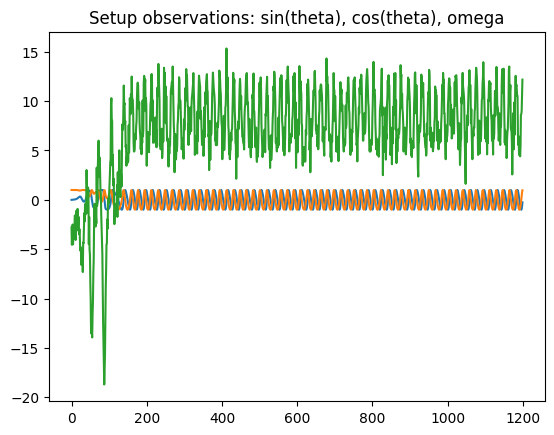

In [11]:
from pathlib import Path

import numpy as np
from stable_baselines3 import A2C

# Hardware sin/cos environment: connects through UnbalancedDisk_exp and returns
# the model observation [sin(theta), cos(theta), omega].
MODEL_NAME = "real_setup_checkpoints/model_100.zip"  # use "a2c_unbalanced_disk_long_dual.zip" for the dual policy
MODEL_CANDIDATES = [
    Path.cwd() / MODEL_NAME,
    Path.cwd() / "ML-for-control-systems-Pendulum" / "gym-unbalanced-disk-master" / "gym_unbalanced_disk" / "examples-connect-to-exp" / MODEL_NAME,
]
MODEL_PATH = next((path for path in MODEL_CANDIDATES if path.exists()), MODEL_CANDIDATES[0])
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Could not find {MODEL_NAME}. Checked: {MODEL_CANDIDATES}")

RUN_STEPS = 1200
DETERMINISTIC = True
ACTION_SIGN = 1.0  # try -1.0 if the real setup polarity is opposite to the simulator
PRINT_FIRST_STEPS = 20

model = A2C.load(MODEL_PATH, device="cpu")
env = gym_unbalanced_disk.UnbalancedDisk_exp_sincos(dt=0.025, umax=umax)

ylist, u_model_list, u_applied_list = [], [], []

try:
    obs, info = env.reset()
    for k in range(RUN_STEPS):
        action, _ = model.predict(obs.astype(np.float32), deterministic=DETERMINISTIC)
        u_model = float(np.asarray(action).reshape(-1)[0])
        u_applied = float(np.clip(ACTION_SIGN * u_model, -umax, umax))

        ylist.append(obs)
        u_model_list.append(u_model)
        u_applied_list.append(u_applied)

        if k < PRINT_FIRST_STEPS:
            print(f"k={k:03d} obs={np.round(obs, 3)} model_u={u_model:+.3f} applied_u={u_applied:+.3f}")

        obs, reward, terminal, truncated, info = env.step(u_applied)
        if terminal or truncated:
            break
finally:
    try:
        env.step(0.0)
    finally:
        env.close()

ylist = np.asarray(ylist)
u_model_list = np.asarray(u_model_list)
u_applied_list = np.asarray(u_applied_list)

print(f"Ran loaded model for {len(u_applied_list)} setup steps")
if len(u_applied_list):
    print(f"max |model_u| = {np.max(np.abs(u_model_list)):.2f} V")
    print(f"max |applied_u| = {np.max(np.abs(u_applied_list)):.2f} V")

plt.plot(u_model_list, label="model")
plt.plot(u_applied_list, label="applied", linestyle="--")
plt.title("Model and applied voltage command")
plt.legend()
plt.show()

plt.plot(ylist)
plt.title("Setup observations: sin(theta), cos(theta), omega")
plt.show()


### Continue training on the real setup

In [14]:
import importlib
import time
from pathlib import Path

import gymnasium as gym
import numpy as np
import usb.core
from stable_baselines3 import A2C
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv

import a2c_unbalanced_disk_train as disk_rl
importlib.reload(disk_rl)

BASE_MODEL_NAME = "real_setup_checkpoints/model_100.zip"  # resume from the 100-episode real checkpoint
EPISODE_NAME_OFFSET = 50
AUGMENTED_MODEL_NAME = "model_200_real_augmented.zip"
REAL_EPISODE_STEPS = 300
REAL_TRAIN_EPISODES = 50
REAL_TRAIN_STEPS = REAL_TRAIN_EPISODES * REAL_EPISODE_STEPS
CHECKPOINT_EVERY_EPISODES = 20
REAL_LEARNING_RATE = 1e-5
MAX_ABS_OMEGA = 35.0
USB_RESET_RETRIES = 3
USB_RETRY_SLEEP = 0.25
USB_TIMEOUT_PENALTY = -5.0

BASE_MODEL_CANDIDATES = [
    Path.cwd() / BASE_MODEL_NAME,
    Path.cwd() / "ML-for-control-systems-Pendulum" / "gym-unbalanced-disk-master" / "gym_unbalanced_disk" / "examples-connect-to-exp" / BASE_MODEL_NAME,
]
base_model_path = next((path for path in BASE_MODEL_CANDIDATES if path.exists()), BASE_MODEL_CANDIDATES[0])
if not base_model_path.exists():
    raise FileNotFoundError(f"Could not find {BASE_MODEL_NAME}")

run_dir = base_model_path.parent.parent / "real_setup_checkpoints_200_to_250"
checkpoint_dir = run_dir
checkpoint_dir.mkdir(parents=True, exist_ok=True)
augmented_model_path = run_dir / AUGMENTED_MODEL_NAME
print(f"Resuming from: {base_model_path}")
print(f"Checkpoint episode offset: {EPISODE_NAME_OFFSET}")
print(f"Saving this run under: {run_dir}")

class RealDiskFineTuneEnv(gym.Env):
    metadata = {"render_modes": ["human"]}

    def __init__(self, dt=0.025, umax=3.0, max_episode_steps=300, max_abs_omega=35.0):
        super().__init__()
        self.dt = dt
        self.umax = umax
        self.max_episode_steps = max_episode_steps
        self.max_abs_omega = max_abs_omega
        self.steps = 0
        self.env = self._make_hardware_env()
        self.observation_space = self.env.observation_space
        self.action_space = gym.spaces.Box(
            low=np.array([-umax], dtype=np.float32),
            high=np.array([umax], dtype=np.float32),
            dtype=np.float32,
        )
        self.last_obs = np.array([0.0, 1.0, 0.0], dtype=np.float32)

    def _make_hardware_env(self):
        return gym_unbalanced_disk.UnbalancedDisk_exp_sincos(dt=self.dt, umax=self.umax)

    def _safe_zero(self):
        try:
            self.env.step(0.0)
        except usb.core.USBError as exc:
            print(f"USB error while sending zero command: {exc}")

    def _reconnect(self):
        try:
            self.env.close()
        except Exception:
            pass
        time.sleep(USB_RETRY_SLEEP)
        self.env = self._make_hardware_env()

    def reset(self, seed=None, options=None):
        if seed is not None:
            np.random.seed(seed)
        self.steps = 0
        last_error = None
        for attempt in range(1, USB_RESET_RETRIES + 1):
            try:
                obs, info = self.env.reset(seed=seed)
                self.last_obs = np.asarray(obs, dtype=np.float32)
                return self.last_obs, info
            except usb.core.USBError as exc:
                last_error = exc
                print(f"USB reset/read error on attempt {attempt}/{USB_RESET_RETRIES}: {exc}")
                self._reconnect()
        raise last_error

    def step(self, action):
        u = float(np.asarray(action, dtype=np.float32).reshape(-1)[0])
        u = float(np.clip(u, -self.umax, self.umax))
        try:
            obs, env_reward, terminated, truncated, info = self.env.step(u)
        except usb.core.USBError as exc:
            self.steps += 1
            self._safe_zero()
            info = {
                "usb_error": str(exc),
                "u": u,
                "safety_truncated": True,
            }
            print(f"USB step/read error; ending episode and continuing training: {exc}")
            return self.last_obs, USB_TIMEOUT_PENALTY, False, True, info

        self.steps += 1
        obs = np.asarray(obs, dtype=np.float32)
        self.last_obs = obs

        theta = float(self.env.th)
        omega = float(self.env.omega)
        reward = disk_rl.external_balance_reward(theta, omega, u, self.umax)
        safety_truncated = abs(omega) > self.max_abs_omega
        time_truncated = self.steps >= self.max_episode_steps

        info = {
            **info,
            "theta": theta,
            "omega": omega,
            "env_reward": float(env_reward),
            "train_reward": float(reward),
            "u": u,
            "safety_truncated": bool(safety_truncated),
        }
        return (
            obs,
            float(reward),
            bool(terminated),
            bool(truncated or time_truncated or safety_truncated),
            info,
        )

    def close(self):
        try:
            self._safe_zero()
        finally:
            self.env.close()

def make_real_env():
    return Monitor(
        RealDiskFineTuneEnv(
            dt=0.025,
            umax=umax,
            max_episode_steps=REAL_EPISODE_STEPS,
            max_abs_omega=MAX_ABS_OMEGA,
        )
    )

train_env = DummyVecEnv([make_real_env])
model = A2C.load(
    base_model_path,
    env=train_env,
    device="cpu",
    custom_objects={
        "learning_rate": REAL_LEARNING_RATE,
        "lr_schedule": lambda _: REAL_LEARNING_RATE,
    },
)
class EpisodeModelCheckpoint(BaseCallback):
    def __init__(self, save_path, name_prefix, every_episodes=50, print_every_episodes=1, episode_name_offset=0):
        super().__init__()
        self.save_path = Path(save_path)
        self.name_prefix = name_prefix
        self.every_episodes = every_episodes
        self.print_every_episodes = print_every_episodes
        self.episodes = 0
        self.episode_name_offset = episode_name_offset
        self.recent_rewards = []

    def _on_step(self):
        infos = self.locals.get("infos", [])
        dones = self.locals.get("dones", [])
        for done, info in zip(dones, infos):
            if done:
                self.episodes += 1
                episode = info.get("episode", {})
                ep_reward = float(episode.get("r", np.nan))
                ep_length = int(episode.get("l", 0))
                if np.isfinite(ep_reward):
                    self.recent_rewards.append(ep_reward)
                    self.recent_rewards = self.recent_rewards[-10:]
                mean10 = float(np.nanmean(self.recent_rewards)) if self.recent_rewards else np.nan
                usb_error = info.get("usb_error")
                safety = info.get("safety_truncated", False)

                if self.episodes % self.print_every_episodes == 0:
                    print(
                        f"episode {self.episodes}/{REAL_TRAIN_EPISODES} "
                        f"(total {self.episodes + self.episode_name_offset}/{self.episode_name_offset + REAL_TRAIN_EPISODES}) | "
                        f"reward={ep_reward:.2f} | mean10={mean10:.2f} | "
                        f"len={ep_length} | steps={self.num_timesteps} | "
                        f"safety={safety} | usb_error={bool(usb_error)}"
                    )

                if self.episodes % self.every_episodes == 0:
                    checkpoint_path = self.save_path / f"model_{self.episodes + self.episode_name_offset}"
                    self.model.save(checkpoint_path)
                    print(f"Saved model checkpoint: {checkpoint_path}.zip")
        return True

checkpoint_callback = EpisodeModelCheckpoint(
    save_path=checkpoint_dir,
    name_prefix=base_model_path.stem + "_real_augmented",
    every_episodes=CHECKPOINT_EVERY_EPISODES,
    print_every_episodes=1,
    episode_name_offset=EPISODE_NAME_OFFSET,
)

try:
    model.learn(
        total_timesteps=REAL_TRAIN_STEPS,
        reset_num_timesteps=False,
        progress_bar=False,
        callback=checkpoint_callback,
    )
    model.save(augmented_model_path)
    print(f"Saved real-setup augmented model: {augmented_model_path}")
finally:
    train_env.close()


Resuming from: c:\Users\thest\Documents\MachineLearningForControlSystems\Assignment\ML-for-control-systems-Pendulum\gym-unbalanced-disk-master\gym_unbalanced_disk\examples-connect-to-exp\real_setup_checkpoints\model_100.zip
Checkpoint episode offset: 50
Saving this run under: c:\Users\thest\Documents\MachineLearningForControlSystems\Assignment\ML-for-control-systems-Pendulum\gym-unbalanced-disk-master\gym_unbalanced_disk\examples-connect-to-exp\real_setup_checkpoints_200_to_250
episode 1/50 (total 51/100) | reward=57.95 | mean10=57.95 | len=300 | steps=329522 | safety=False | usb_error=False
episode 2/50 (total 52/100) | reward=55.55 | mean10=56.75 | len=300 | steps=329822 | safety=False | usb_error=False
episode 3/50 (total 53/100) | reward=24.31 | mean10=45.93 | len=300 | steps=330122 | safety=False | usb_error=False
episode 4/50 (total 54/100) | reward=34.55 | mean10=43.09 | len=300 | steps=330422 | safety=False | usb_error=False
episode 5/50 (total 55/100) | reward=9.29 | mean10=36